In [4]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
from ast import literal_eval
from scipy.stats import wilcoxon, mannwhitneyu, gaussian_kde
from scipy.stats import circmean
import statsmodels.formula.api as smf

In [31]:
key_stimuli = ('ade', 'cad_2.5mm', 'ph4.5', 'qui_2.5mm', 'fex1', 'kw', 'pro_2.5mm')
# key_stimuli = ('cad_250um', 'qui_250um', 'fex2', 'pro_250um')
# key_stimuli = ('cad_25um', 'qui_25um', 'fex3', 'pro_25um')

## applying filtering and preprocessing steps 
sampling_frequency = 60.85  # Original frequency in Hz
window_size_ms = 100  # Window size in milliseconds
window_size_samples = int(sampling_frequency * (window_size_ms / 1000.0))  # Convert to samples
stim_onset = 3180

# # --- Stimulus Labels & Colors for plotting ---
stimulus_labels = {
    "ade": "Ade", "cad_2.5mm": "Cad", "fex1": "Fex",
    "kw": "Kin", "ph4.5": "HCl", "pro_2.5mm": "Pro", "qui_2.5mm": "Qun",
    "cad_250um": "Cad Int.", "fex2": "Fex Int.", "pro_250um": "Pro Int.", "qui_250um": "Qun Int.",
    "cad_25um": "Cad Low", "fex3": "Fex Low", "pro_25um": "Pro Low", "qui_25um": "Qun Low"
}

stimulus_colors = {
    "Ade": "plum", "Cad": "mediumorchid", "Fex": "limegreen",
    "Kin": "forestgreen", "HCl": "fuchsia", "Pro": "olive", "Qun": "deeppink",
    "Cad Int.": "violet", "Fex Int.": "seagreen",
    "Pro Int.": "olivedrab", "Qun Int.": "palevioletred",
    "Cad Low": "plum", "Fex Low": "springgreen",
    "Pro Low": "yellowgreen", "Qun Low": "pink"
}

stimulus_order = ["Ade", "Cad", "HCl", "Qun", "Fex", "Kin", "Pro"]
# stimulus_order = ["Cad Int.", "Qun Int.", "Fex Int.", "Pro Int."]
# stimulus_order = ["Cad Low", "Qun Low", "Fex Low", "Pro Low"]


In [32]:
def load_behavior_data(path, suffix):
    df = pd.read_csv(path)
    
    # standardize fish_id
    df['fish_id'] = df['fish_id'].astype(str) + suffix
    
    # safely parse stringified lists
    df['angles'] = df['angles'].apply(literal_eval)
    df['bout_indx'] = df['bouts'].apply(literal_eval)
    
    return df

def classify_asymm_bouts(row, left_threshold=-0.066, right_threshold=0.066, sampling_rate=60.85, duration_ms=70):
    asymmetric_flags = []
    directions = []

    bouts = row['bout_indx']
    tail_angle = row['angles']
    duration_frames = int((duration_ms / 1000) * sampling_rate)

    for bout in bouts:
        if len(bout) < 2:
            continue

        bout_start = bout[0]
        bout_duration = min(duration_frames, len(bout))
        angles = np.array(tail_angle[bout_start:bout_start + bout_duration])

        laterality_index = circmean(angles, high=np.pi, low=-np.pi)

        if laterality_index < left_threshold:
            asymmetric_flags.append(True)
            directions.append("left")
        elif laterality_index > right_threshold:
            asymmetric_flags.append(True)
            directions.append("right")
        else:
            asymmetric_flags.append(False)
            directions.append("straight")

    return pd.Series([asymmetric_flags, directions])

In [33]:
bhv_fb = load_behavior_data(
    '/Volumes/LaCie/larval_HuC/behavior/7dpf_fb_behavior_traces_posture.csv',
    '_fb'
)

bhv_hb = load_behavior_data(
    '/Volumes/LaCie/larval_HuC/behavior/7dpf_hb_behavior_traces_posture.csv',
    '_hb'
)

bhv = pd.concat([bhv_fb, bhv_hb], ignore_index=True)

stimulus_df = bhv[bhv['stimulus'].isin(key_stimuli)]

stimulus_df = stimulus_df.copy()
stimulus_df['fish_id_clean'] = stimulus_df['fish_id'].str.replace(
    r'(_fb|_hb)$', '', regex=True
)

stimulus_df[['asymmetric_bout', 'bout_direction']] = stimulus_df.apply(
    lambda row: classify_asymm_bouts(row, left_threshold=-0.06, right_threshold=0.06),
    axis=1
)

In [34]:
sampling_freq = 60.85  # Frames per second
window_sec = 20  # Time window in seconds
window_frames = int(window_sec * sampling_freq)
stimulus_onset_frame = 3225 #53 seconds 


def calculate_asymmetric_bout_frequency(bouts, asymmetric_flags, stimulus_onset_frame, window_frames, sampling_freq):
    """
    Calculates the frequency of asymmetric bouts before and after stimulus onset.

    Parameters:
    - bouts: List of bout indices.
    - asymmetric_flags: List of True/False values indicating if the bout is asymmetric.
    - stimulus_onset_frame: Frame where stimulus starts.
    - window_frames: Number of frames in the pre- and post-stimulus time window.
    - sampling_freq: Sampling frequency (frames per second).

    Returns:
    - pre_stim_asym_freq: Frequency of asymmetric bouts pre-stimulus.
    - post_stim_asym_freq: Frequency of asymmetric bouts post-stimulus.
    """
    # Select only asymmetric bouts
    asymmetric_bouts = [b for b, is_asym in zip(bouts, asymmetric_flags) if is_asym]

    # Split into pre-stim and post-stim
    pre_stim_bouts = [bout for bout in asymmetric_bouts if stimulus_onset_frame - window_frames <= bout[0] < stimulus_onset_frame]
    post_stim_bouts = [bout for bout in asymmetric_bouts if stimulus_onset_frame <= bout[0] < stimulus_onset_frame + window_frames]

    # Compute durations in seconds
    pre_stim_duration = window_frames / sampling_freq
    post_stim_duration = window_frames / sampling_freq

    # Compute frequency (bouts per second)
    pre_stim_asym_freq = len(pre_stim_bouts) / pre_stim_duration if pre_stim_duration > 0 else 0
    post_stim_asym_freq = len(post_stim_bouts) / post_stim_duration if post_stim_duration > 0 else 0

    return pre_stim_asym_freq, post_stim_asym_freq

asym_bout_freq_prestim = []
asym_bout_freq_poststim = []

for index, row in stimulus_df.iterrows():
    bouts = row['bout_indx']
    asymmetric_flags = row['asymmetric_bout']  # List of True/False per bout

    pre_asym_freq, post_asym_freq = calculate_asymmetric_bout_frequency(
        bouts, asymmetric_flags, stimulus_onset_frame, window_frames, sampling_freq
    )

    asym_bout_freq_prestim.append(pre_asym_freq)
    asym_bout_freq_poststim.append(post_asym_freq)

# Save to DataFrame
stimulus_df['asym_bout_freq_prestim'] = asym_bout_freq_prestim
stimulus_df['asym_bout_freq_poststim'] = asym_bout_freq_poststim

In [35]:
stimulus_df["session"] = stimulus_df["fish_id"].str.extract("(fb|hb)")

In [36]:
df_long = stimulus_df.melt(
    id_vars=["fish_id_clean","session", "stimulus", "trial_number"],
    value_vars=["asym_bout_freq_prestim", "asym_bout_freq_poststim"],
    var_name="condition",
    value_name="asym_bout_frequency"
)

df_long["condition"] = df_long["condition"].replace({
    "asym_bout_freq_prestim": "Prestim",
    "asym_bout_freq_poststim": "Poststim"
})

# force baseline
df_long["condition"] = pd.Categorical(
    df_long["condition"],
    categories=["Prestim", "Poststim"]
)



results = []

for stim in df_long["stimulus"].unique():

    stim_df = df_long[df_long["stimulus"] == stim]

    model = smf.mixedlm(
        "asym_bout_frequency ~ condition",
        stim_df,
        groups=stim_df["fish_id_clean"],
        vc_formula={"session": "0 + C(session)"}
    )

    fit = model.fit()

    p_value = fit.pvalues.get("condition[T.Poststim]", None)

    results.append({
        "stimulus": stim,
        "n_fish": stim_df["fish_id_clean"].nunique(),
        "p_value": p_value
    })

mixed_results = pd.DataFrame(results)
print(mixed_results)

    stimulus  n_fish   p_value
0  cad_250um      10  0.943049
1       fex2      10  0.667762
2  pro_250um      10  0.495074
3  qui_250um      10  0.190148


/Users/bethanjenkins/opt/anaconda3/envs/sense/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/bethanjenkins/opt/anaconda3/envs/sense/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/bethanjenkins/opt/anaconda3/envs/sense/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


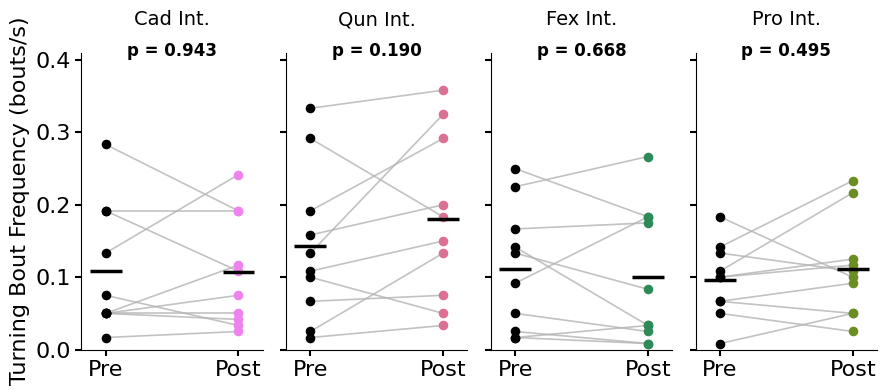

In [37]:
df_long = stimulus_df.melt(
    id_vars=["fish_id_clean", "stimulus", "trial_number"],
    value_vars=["asym_bout_freq_prestim", "asym_bout_freq_poststim"],
    var_name="condition",
    value_name="asym_bout_frequency"
)

df_long["condition"] = df_long["condition"].replace({
    "asym_bout_freq_prestim": "Prestim",
    "asym_bout_freq_poststim": "Poststim"
})

# convert stimulus names for plotting
df_long["stimulus"] = df_long["stimulus"].replace(stimulus_labels)


# -----------------------------
# 2. Average across trials within each fish
# -----------------------------
fish_plot_df = (
    df_long.groupby(["fish_id_clean", "stimulus", "condition"], as_index=False)["asym_bout_frequency"]
    .mean()
)

fish_plot_df["stimulus"] = pd.Categorical(
    fish_plot_df["stimulus"],
    categories=stimulus_order,
    ordered=True
)

# -----------------------------
# 3. Prepare p-values for plotting
# -----------------------------
mixed_results_plot = mixed_results.copy()
mixed_results_plot["stimulus"] = mixed_results_plot["stimulus"].replace(stimulus_labels)

# -----------------------------
# 4. Plot
# -----------------------------
fig, axes = plt.subplots(1, len(stimulus_order), figsize=(9, 4), sharey=True)

for i, stim in enumerate(stimulus_order):
    ax = axes[i]

    stim_df = fish_plot_df[fish_plot_df["stimulus"] == stim]

    paired = stim_df.pivot_table(
        index="fish_id_clean",
        columns="condition",
        values="asym_bout_frequency",
        aggfunc="mean"
    ).dropna()

    if paired.empty:
        ax.set_title(stim)
        continue

    # paired lines
    for _, row in paired.iterrows():
        ax.plot(
            [0, 1],
            [row["Prestim"], row["Poststim"]],
            color="0.7",
            linewidth=1.2,
            alpha=0.8,
            zorder=1
        )

    # individual fish points
    ax.scatter(
        np.zeros(len(paired)),
        paired["Prestim"],
        color="black",
        s=35,
        zorder=2
    )

    ax.scatter(
        np.ones(len(paired)),
        paired["Poststim"],
        color=stimulus_colors.get(stim, "gray"),
        s=35,
        zorder=2
    )

    # mean bars
    pre_mean = paired["Prestim"].mean()
    post_mean = paired["Poststim"].mean()

    ax.hlines(pre_mean, -0.12, 0.12, color="black", linewidth=2.5, zorder=3)
    ax.hlines(post_mean, 0.88, 1.12, color="black", linewidth=2.5, zorder=3)

    # numeric p-value
    p_row = mixed_results_plot[mixed_results_plot["stimulus"] == stim]
    if not p_row.empty:
        p = p_row.iloc[0]["p_value"]
        y = 0.4
        ax.text(
            0.5,
            y,
            f"p = {p:.3f}",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold"
        )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Pre", "Post"], fontsize=16)
    ax.set_title(stim, fontsize=14, pad=20)
    plt.ylim(0,0.41)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", width=1.5, length=4, direction="out", labelsize=16)

axes[0].set_ylabel("Turning Bout Frequency (bouts/s)", fontsize=16)

plt.tight_layout()
plt.savefig(f"/Users/bethanjenkins/Documents/valence_paper_code/FiNA/figures/7dpf_assym_bout_freq_mixed_effect_model_int_concs.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

In [17]:

fish_summary_df = (
    df_long.groupby(["fish_id_clean", "stimulus", "condition"])["asym_bout_frequency"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .rename(columns={
        "mean": "fish_mean",
        "std": "fish_std",
        "count": "n_observations"
    })
)

# optional: pretty stimulus labels
fish_summary_df["stimulus"] = fish_summary_df["stimulus"].replace(stimulus_labels)

print(fish_summary_df.head())


# ---------------------------------
# 2. Mixed model results
# ---------------------------------
mixed_results_df = mixed_results.copy()
mixed_results_df["stimulus"] = mixed_results_df["stimulus"].replace(stimulus_labels)

print(mixed_results_df)


# ---------------------------------
# 3. Save both
# ---------------------------------
fish_summary_df.to_csv(
    "/Users/bethanjenkins/Documents/valence_paper_code/FiNA/asym_bout_fish_Intermediate_concs_summary.csv",
    index=False
)

mixed_results_df.to_csv(
    "/Users/bethanjenkins/Documents/valence_paper_code/FiNA/asym_bout_Intermediate_concs_mixed_model_results.csv",
    index=False
)

  fish_id_clean stimulus condition  fish_mean  fish_std  n_observations
0        230713      Ade  Poststim   0.091667  0.066458               6
1        230713      Ade   Prestim   0.050000  0.063246               6
2        230713      Cad  Poststim   0.191667  0.241695               6
3        230713      Cad   Prestim   0.066667  0.098319               6
4        230713      Fex  Poststim   0.066667  0.051640               6
  stimulus  n_fish   p_value
0      Ade      10  0.018173
1      Cad      10  0.005730
2      Fex      10  0.219643
3      Kin      10  0.378555
4      HCl      10  0.021291
5      Pro      10  0.088032
6      Qun      10  0.023808


In [94]:
def calculate_straight_bout_frequency(bouts, bout_directions, stimulus_onset_frame, window_frames, sampling_freq):
    """
    Calculates the frequency of straight bouts before and after stimulus onset.

    Parameters:
    - bouts: List of bout indices.
    - bout_directions: List of bout direction labels ('left', 'right', 'straight').
    - stimulus_onset_frame: Frame where stimulus starts.
    - window_frames: Number of frames in the pre- and post-stimulus time window.
    - sampling_freq: Sampling frequency (frames per second).

    Returns:
    - pre_stim_straight_freq: Frequency of straight bouts pre-stimulus.
    - post_stim_straight_freq: Frequency of straight bouts post-stimulus.
    """
    # Select only straight bouts
    straight_bouts = [b for b, direction in zip(bouts, bout_directions) if direction == 'straight']

    # Split into pre-stim and post-stim
    pre_stim_bouts = [bout for bout in straight_bouts if stimulus_onset_frame - window_frames <= bout[0] < stimulus_onset_frame]
    post_stim_bouts = [bout for bout in straight_bouts if stimulus_onset_frame <= bout[0] < stimulus_onset_frame + window_frames]

    # Compute durations in seconds
    pre_stim_duration = window_frames / sampling_freq
    post_stim_duration = window_frames / sampling_freq

    # Compute frequency (bouts per second)
    pre_stim_straight_freq = len(pre_stim_bouts) / pre_stim_duration if pre_stim_duration > 0 else 0
    post_stim_straight_freq = len(post_stim_bouts) / post_stim_duration if post_stim_duration > 0 else 0

    return pre_stim_straight_freq, post_stim_straight_freq


straight_bout_freq_prestim, straight_bout_freq_poststim = [], []

for _, row in stimulus_df.iterrows():
    bouts = row['bout_indx']
    bout_directions = row['bout_direction']
    
    # Compute straight bout frequency
    pre_rate, post_rate = calculate_straight_bout_frequency(
        bouts, bout_directions, stimulus_onset_frame=3225, window_frames=int(20 * 60.85), sampling_freq=60.85
    )
    
    straight_bout_freq_prestim.append(pre_rate)
    straight_bout_freq_poststim.append(post_rate)

# Store results in DataFrame
stimulus_df['straight_bout_freq_prestim'] = straight_bout_freq_prestim
stimulus_df['straight_bout_freq_poststim'] = straight_bout_freq_poststim

In [95]:
df_long = stimulus_df.melt(
    id_vars=["fish_id_clean","session", "stimulus", "trial_number"],
    value_vars=["straight_bout_freq_prestim", "straight_bout_freq_poststim"],
    var_name="condition",
    value_name="straight_bout_frequency"
)

df_long["condition"] = df_long["condition"].replace({
    "straight_bout_freq_prestim": "Prestim",
    "straight_bout_freq_poststim": "Poststim"
})

# force baseline
df_long["condition"] = pd.Categorical(
    df_long["condition"],
    categories=["Prestim", "Poststim"]
)

import statsmodels.formula.api as smf

results = []

for stim in df_long["stimulus"].unique():

    stim_df = df_long[df_long["stimulus"] == stim]

    model = smf.mixedlm(
        "straight_bout_frequency ~ condition",
        stim_df,
        groups=stim_df["fish_id_clean"],
        vc_formula={"session": "0 + C(session)"}
    )

    fit = model.fit()

    p_value = fit.pvalues.get("condition[T.Poststim]", None)

    results.append({
        "stimulus": stim,
        "n_fish": stim_df["fish_id_clean"].nunique(),
        "p_value": p_value
    })

mixed_results = pd.DataFrame(results)
print(mixed_results)

    stimulus  n_fish   p_value
0        ade      10  1.000000
1  cad_2.5mm      10  0.796000
2       fex1      10  0.699281
3         kw      10  0.741498
4      ph4.5      10  0.793390
5  pro_2.5mm      10  0.506652
6  qui_2.5mm      10  0.957160


/Users/bethanjenkins/opt/anaconda3/envs/sense/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


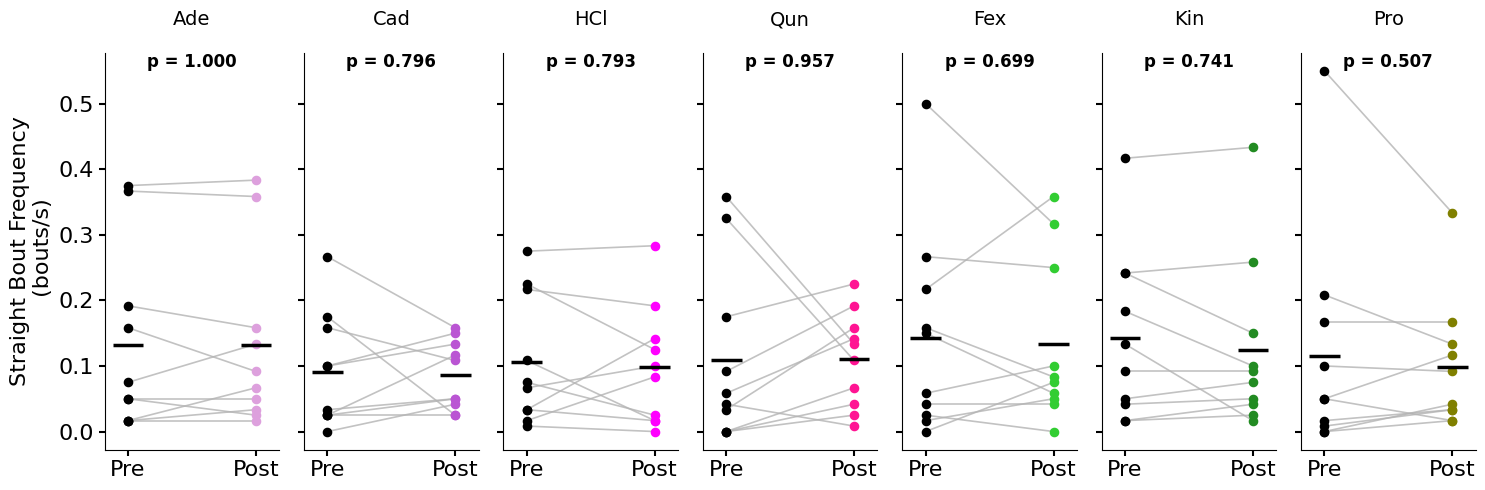

In [97]:
df_long = stimulus_df.melt(
    id_vars=["fish_id_clean", "stimulus", "trial_number"],
    value_vars=["straight_bout_freq_prestim", "straight_bout_freq_poststim"],
    var_name="condition",
    value_name="straight_bout_frequency"
)

df_long["condition"] = df_long["condition"].replace({
    "straight_bout_freq_prestim": "Prestim",
    "straight_bout_freq_poststim": "Poststim"
})

# convert stimulus names for plotting
df_long["stimulus"] = df_long["stimulus"].replace(stimulus_labels)

# if your frequencies are still in bouts/sec, convert to bouts/min:
# df_long["straight_bout_frequency"] *= 60

# -----------------------------
# 2. Average across trials within each fish
# -----------------------------
fish_plot_df = (
    df_long.groupby(["fish_id_clean", "stimulus", "condition"], as_index=False)["straight_bout_frequency"]
    .mean()
)

fish_plot_df["stimulus"] = pd.Categorical(
    fish_plot_df["stimulus"],
    categories=stimulus_order,
    ordered=True
)

# -----------------------------
# 3. Prepare p-values for plotting
# -----------------------------
mixed_results_plot = mixed_results.copy()
mixed_results_plot["stimulus"] = mixed_results_plot["stimulus"].replace(stimulus_labels)

# -----------------------------
# 4. Plot
# -----------------------------
fig, axes = plt.subplots(1, len(stimulus_order), figsize=(15, 5), sharey=True)

for i, stim in enumerate(stimulus_order):
    ax = axes[i]

    stim_df = fish_plot_df[fish_plot_df["stimulus"] == stim]

    paired = stim_df.pivot_table(
        index="fish_id_clean",
        columns="condition",
        values="straight_bout_frequency",
        aggfunc="mean"
    ).dropna()

    if paired.empty:
        ax.set_title(stim)
        continue

    # paired lines
    for _, row in paired.iterrows():
        ax.plot(
            [0, 1],
            [row["Prestim"], row["Poststim"]],
            color="0.7",
            linewidth=1.2,
            alpha=0.8,
            zorder=1
        )

    # individual fish points
    ax.scatter(
        np.zeros(len(paired)),
        paired["Prestim"],
        color="black",
        s=35,
        zorder=2
    )

    ax.scatter(
        np.ones(len(paired)),
        paired["Poststim"],
        color=stimulus_colors.get(stim, "gray"),
        s=35,
        zorder=2
    )

    # mean bars
    pre_mean = paired["Prestim"].mean()
    post_mean = paired["Poststim"].mean()

    ax.hlines(pre_mean, -0.12, 0.12, color="black", linewidth=2.5, zorder=3)
    ax.hlines(post_mean, 0.88, 1.12, color="black", linewidth=2.5, zorder=3)

    # numeric p-value
    p_row = mixed_results_plot[mixed_results_plot["stimulus"] == stim]
    if not p_row.empty:
        p = p_row.iloc[0]["p_value"]
        y = 0.55
        ax.text(
            0.5,
            y,
            f"p = {p:.3f}",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold"
        )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Pre", "Post"], fontsize=16)
    ax.set_title(stim, fontsize=14, pad=20)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", width=1.5, length=4, direction="out", labelsize=16)

axes[0].set_ylabel("Straight Bout Frequency\n (bouts/s)", fontsize=16)

plt.tight_layout()
# plt.savefig(f"/Users/bethanjenkins/Documents/valence_paper_code/FiNA/figures/7dpf_straight_bout_freq_Low_cons_mixed_effect_model.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

In [70]:

fish_summary_df = (
    df_long.groupby(["fish_id_clean", "stimulus", "condition"])["straight_bout_frequency"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .rename(columns={
        "mean": "fish_mean",
        "std": "fish_std",
        "count": "n_observations"
    })
)

# optional: pretty stimulus labels
fish_summary_df["stimulus"] = fish_summary_df["stimulus"].replace(stimulus_labels)

print(fish_summary_df.head())


# ---------------------------------
# 2. Mixed model results
# ---------------------------------
mixed_results_df = mixed_results.copy()
mixed_results_df["stimulus"] = mixed_results_df["stimulus"].replace(stimulus_labels)

print(mixed_results_df)


# ---------------------------------
# 3. Save both
# ---------------------------------
fish_summary_df.to_csv(
    "/Users/bethanjenkins/Documents/valence_paper_code/FiNA/straight_bout_fish_Low_conc_summary.csv",
    index=False
)

mixed_results_df.to_csv(
    "/Users/bethanjenkins/Documents/valence_paper_code/FiNA/straight_bout_mixed_model_Low_conc_results.csv",
    index=False
)

  fish_id_clean stimulus condition  fish_mean  fish_std  n_observations
0        230713  Cad Low  Poststim   0.058333  0.073598               6
1        230713  Cad Low   Prestim   0.050000  0.063246               6
2        230713  Fex Low  Poststim   0.008333  0.020412               6
3        230713  Fex Low   Prestim   0.033333  0.025820               6
4        230713  Pro Low  Poststim   0.033333  0.040825               6
  stimulus  n_fish   p_value
0  Cad Low      10  0.469083
1  Fex Low      10  0.430239
2  Pro Low      10  0.810608
3  Qun Low      10  0.907970


In [99]:
# ---------------------------------
# 1. Define valence groups
# ---------------------------------
positive_stims = ["fex1", "kw", "pro_2.5mm"]
negative_stims = ["ade", "cad_2.5mm", "ph4.5", "qui_2.5mm"]

def stim_to_valence(stim):
    if stim in positive_stims:
        return "POS"
    elif stim in negative_stims:
        return "NEG"
    else:
        return np.nan

# ---------------------------------
# 2. Make long dataframe
# ---------------------------------
df_long = stimulus_df.melt(
    id_vars=["fish_id_clean", "stimulus", "trial_number"],
    value_vars=["pre_stim_straight_freq", "post_stim_straight_freq"],
    var_name="condition",
    value_name="straight_bout_frequency"
)

df_long["condition"] = df_long["condition"].replace({
    "pre_stim_straight_freq": "Prestim",
    "post_stim_straight_freq": "Poststim"
})

# if still in bouts/sec, uncomment:
# df_long["straight_bout_frequency"] *= 60

# add valence from raw stimulus names
df_long["valence"] = df_long["stimulus"].apply(stim_to_valence)

# drop anything unmapped
df_long = df_long.dropna(subset=["valence"]).copy()

# ---------------------------------
# 3. Average across trials within each fish and valence
# ---------------------------------
fish_plot_df = (
    df_long.groupby(["fish_id_clean", "valence", "condition"], as_index=False)["straight_bout_frequency"]
    .mean()
)

valence_order = ["POS", "NEG"]
valence_labels = {"POS": "Appetitive", "NEG": "Aversive"}
valence_colors = {"POS": "green", "NEG": "magenta"}

# ---------------------------------
# 4. Fish-level paired Wilcoxon by valence
# ---------------------------------
results = []

for valence, g in fish_plot_df.groupby("valence"):
    paired = g.pivot_table(
        index="fish_id_clean",
        columns="condition",
        values="straight_bout_frequency",
        aggfunc="mean"
    ).dropna()

    if paired.empty:
        continue

    stat, p = wilcoxon(paired["Prestim"], paired["Poststim"])

    results.append({
        "valence": valence,
        "n_fish": paired.index.nunique(),
        "wilcoxon_p": p,
        "prestim_mean": paired["Prestim"].mean(),
        "prestim_std": paired["Prestim"].std(ddof=1),
        "poststim_mean": paired["Poststim"].mean(),
        "poststim_std": paired["Poststim"].std(ddof=1),
    })

valence_results = pd.DataFrame(results)
print(valence_results)

# ---------------------------------
# 5. Plot
# ---------------------------------
fig, axes = plt.subplots(1, len(valence_order), figsize=(8, 5), sharey=True)

if len(valence_order) == 1:
    axes = [axes]

for i, valence in enumerate(valence_order):
    ax = axes[i]

    g = fish_plot_df[fish_plot_df["valence"] == valence]

    paired = g.pivot_table(
        index="fish_id_clean",
        columns="condition",
        values="straight_bout_frequency",
        aggfunc="mean"
    ).dropna()

    if paired.empty:
        ax.set_title(valence_labels[valence])
        continue

    # paired lines
    for _, row in paired.iterrows():
        ax.plot(
            [0, 1],
            [row["Prestim"], row["Poststim"]],
            color="0.7",
            linewidth=1.2,
            alpha=0.8,
            zorder=1
        )

    # individual fish points
    ax.scatter(
        np.zeros(len(paired)),
        paired["Prestim"],
        color="black",
        s=35,
        zorder=2
    )

    ax.scatter(
        np.ones(len(paired)),
        paired["Poststim"],
        color=valence_colors[valence],
        s=35,
        zorder=2
    )

    # mean bars
    pre_mean = paired["Prestim"].mean()
    post_mean = paired["Poststim"].mean()

    ax.hlines(pre_mean, -0.12, 0.12, color="black", linewidth=2.5, zorder=3)
    ax.hlines(post_mean, 0.88, 1.12, color="black", linewidth=2.5, zorder=3)

    # numeric p-value
    p_row = valence_results[valence_results["valence"] == valence]
    if not p_row.empty:
        p = p_row.iloc[0]["wilcoxon_p"]
        y = 0.4
        ax.text(
            0.5,
            y,
            f"p = {p:.3f}",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold"
        )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Pre", "Post"], fontsize=16)
    ax.set_title(valence_labels[valence], fontsize=16, pad=20)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", width=1.5, length=4, direction="out", labelsize=16)

axes[0].set_ylabel("Straight Bout Frequency \n(bouts/s)", fontsize=20)

plt.tight_layout()
# plt.savefig(f"/Users/bethanjenkins/Documents/valence_paper_code/FiNA/figures/7dpf_straight_valence_bout_freq_mixed_effect_model.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['pre_stim_straight_freq', 'post_stim_straight_freq']"

  valence  n_fish  wilcoxon_p
0     NEG      10    0.027344
1     POS      10    0.138672


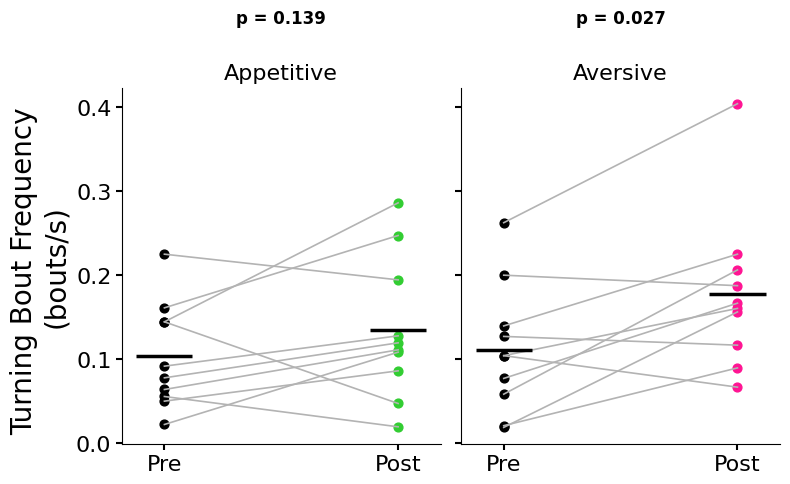

In [100]:
# -----------------------------
# 1. Define valence groups
# -----------------------------
positive_stims = ["fex1", "kw", "pro_2.5mm"]
negative_stims = ["ade", "cad_2.5mm", "ph4.5", "qui_2.5mm"]

def stim_to_valence(stim):
    if stim in positive_stims:
        return "POS"
    elif stim in negative_stims:
        return "NEG"
    else:
        return np.nan


# -----------------------------
# 2. Reshape dataframe
# -----------------------------
df_long = stimulus_df.melt(
    id_vars=["fish_id_clean", "stimulus", "trial_number"],
    value_vars=["asym_bout_freq_prestim", "asym_bout_freq_poststim"],
    var_name="condition",
    value_name="asym_bout_frequency"
)

df_long["condition"] = df_long["condition"].replace({
    "asym_bout_freq_prestim": "Prestim",
    "asym_bout_freq_poststim": "Poststim"
})

# convert to bouts/min if needed
# df_long["asym_bout_frequency"] *= 60

# add valence
df_long["valence"] = df_long["stimulus"].apply(stim_to_valence)

df_long = df_long.dropna(subset=["valence"])


# -----------------------------
# 3. Average across trials within fish
# -----------------------------
fish_df = (
    df_long.groupby(["fish_id_clean","valence","condition"],as_index=False)
    ["asym_bout_frequency"].mean()
)

valence_order = ["POS","NEG"]
valence_labels = {"POS":"Appetitive","NEG":"Aversive"}
valence_colors = {"POS":"limegreen","NEG":"deeppink"}


# -----------------------------
# 4. Statistics
# -----------------------------
results = []

for valence, g in fish_df.groupby("valence"):

    paired = g.pivot_table(
        index="fish_id_clean",
        columns="condition",
        values="asym_bout_frequency"
    ).dropna()

    stat,p = wilcoxon(paired["Prestim"], paired["Poststim"])

    results.append({
        "valence":valence,
        "n_fish":paired.index.nunique(),
        "wilcoxon_p":p
    })

valence_results = pd.DataFrame(results)
print(valence_results)


# -----------------------------
# 5. Plot
# -----------------------------
fig,axes = plt.subplots(1,2,figsize=(8,5),sharey=True)

for i,valence in enumerate(valence_order):

    ax = axes[i]

    g = fish_df[fish_df["valence"]==valence]

    paired = g.pivot_table(
        index="fish_id_clean",
        columns="condition",
        values="asym_bout_frequency"
    ).dropna()

    # paired lines
    for _,row in paired.iterrows():
        ax.plot([0,1],[row["Prestim"],row["Poststim"]],
                color="0.7",linewidth=1.2)

    # points
    ax.scatter(np.zeros(len(paired)),
               paired["Prestim"],
               color="black",
               s=40)

    ax.scatter(np.ones(len(paired)),
               paired["Poststim"],
               color=valence_colors[valence],
               s=40)

    # mean bars
    ax.hlines(paired["Prestim"].mean(),-0.12,0.12,color="black",linewidth=2.5)
    ax.hlines(paired["Poststim"].mean(),0.88,1.12,color="black",linewidth=2.5)

    # p-value
    p = valence_results[valence_results["valence"]==valence]["wilcoxon_p"].values[0]

    ax.text(
        0.5,
        0.5,
        f"p = {p:.3f}",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xticks([0,1])
    ax.set_xticklabels(["Pre","Post"],fontsize=20)
    ax.set_title(valence_labels[valence],fontsize=16)
    ax.tick_params(axis="both", width=1.5, length=4, direction="out", labelsize=16)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Turning Bout Frequency \n(bouts/s)",fontsize=20)

plt.tight_layout()
# plt.savefig(f"/Users/bethanjenkins/Documents/valence_paper_code/FiNA/figures/7dpf_asymm_valence_bout_freq_mixed_effect_model.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

In [143]:
def calculate_all_bout_frequency(
    bouts,
    stimulus_onset_frame,
    window_frames,
    sampling_freq
):

    # split bouts
    pre_stim_bouts = [
        b for b in bouts
        if stimulus_onset_frame - window_frames <= b[0] < stimulus_onset_frame
    ]

    post_stim_bouts = [
        b for b in bouts
        if stimulus_onset_frame <= b[0] < stimulus_onset_frame + window_frames
    ]

    # duration in seconds
    duration = window_frames / sampling_freq

    # frequency (bouts/sec)
    pre_freq = len(pre_stim_bouts) / duration
    post_freq = len(post_stim_bouts) / duration

    return pre_freq, post_freq

In [144]:
pre_all = []
post_all = []

window_frames = int(20 * 60.85)

for _, row in stimulus_df.iterrows():

    bouts = row["bout_indx"]

    pre, post = calculate_all_bout_frequency(
        bouts=bouts,
        stimulus_onset_frame=3225,
        window_frames=window_frames,
        sampling_freq=60.85
    )

    pre_all.append(pre)
    post_all.append(post)

stimulus_df["all_bout_freq_prestim"] = pre_all
stimulus_df["all_bout_freq_poststim"] = post_all

stimulus_df["session"] = stimulus_df["fish_id"].str.extract("(fb|hb)")

In [145]:
df_long = stimulus_df.melt(
    id_vars=["fish_id_clean", "stimulus", "trial_number", "session"],
    value_vars=["all_bout_freq_prestim", "all_bout_freq_poststim"],
    var_name="condition",
    value_name="bout_frequency"
)

df_long["condition"] = df_long["condition"].replace({
    "all_bout_freq_prestim":"Prestim",
    "all_bout_freq_poststim":"Poststim"
})

fish_df = (
    df_long.groupby(
        ["fish_id_clean","stimulus","condition"],
        observed=False
    )["bout_frequency"]
    .mean()
    .reset_index()
)

In [146]:
# set condition baseline once
df_long["condition"] = pd.Categorical(
    df_long["condition"],
    categories=["Prestim", "Poststim"]
)

results = []

for stim in df_long["stimulus"].unique():

    stim_df = df_long[df_long["stimulus"] == stim].copy()

    model = smf.mixedlm(
        "bout_frequency ~ condition",
        stim_df,
        groups=stim_df["fish_id_clean"],          # random fish effect
        vc_formula={"session": "0 + C(session)"}  # random session effect
    )

    fit = model.fit()

    # safely extract p-value
    if "condition[T.Poststim]" in fit.pvalues:
        p_value = fit.pvalues["condition[T.Poststim]"]
    else:
        p_value = None

    results.append({
        "stimulus": stim,
        "n_fish": stim_df["fish_id_clean"].nunique(),
        "p_value": p_value
    })

mixed_results_all_bouts = pd.DataFrame(results)

print(mixed_results_all_bouts)

/Users/bethanjenkins/opt/anaconda3/envs/sense/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/bethanjenkins/opt/anaconda3/envs/sense/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/bethanjenkins/opt/anaconda3/envs/sense/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/bethanjenkins/opt/anaconda3/envs/sense/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/bethanjenkins/opt/anaconda3/envs/sense/lib/python3.10/site-packages/s

    stimulus  n_fish       p_value
0        ade      10  4.345513e-28
1  cad_2.5mm      10  4.899841e-22
2       fex1      10  2.662227e-13
3         kw      10  6.512764e-07
4      ph4.5      10  5.752373e-16
5  pro_2.5mm      10  5.097973e-19
6  qui_2.5mm      10  1.801134e-17


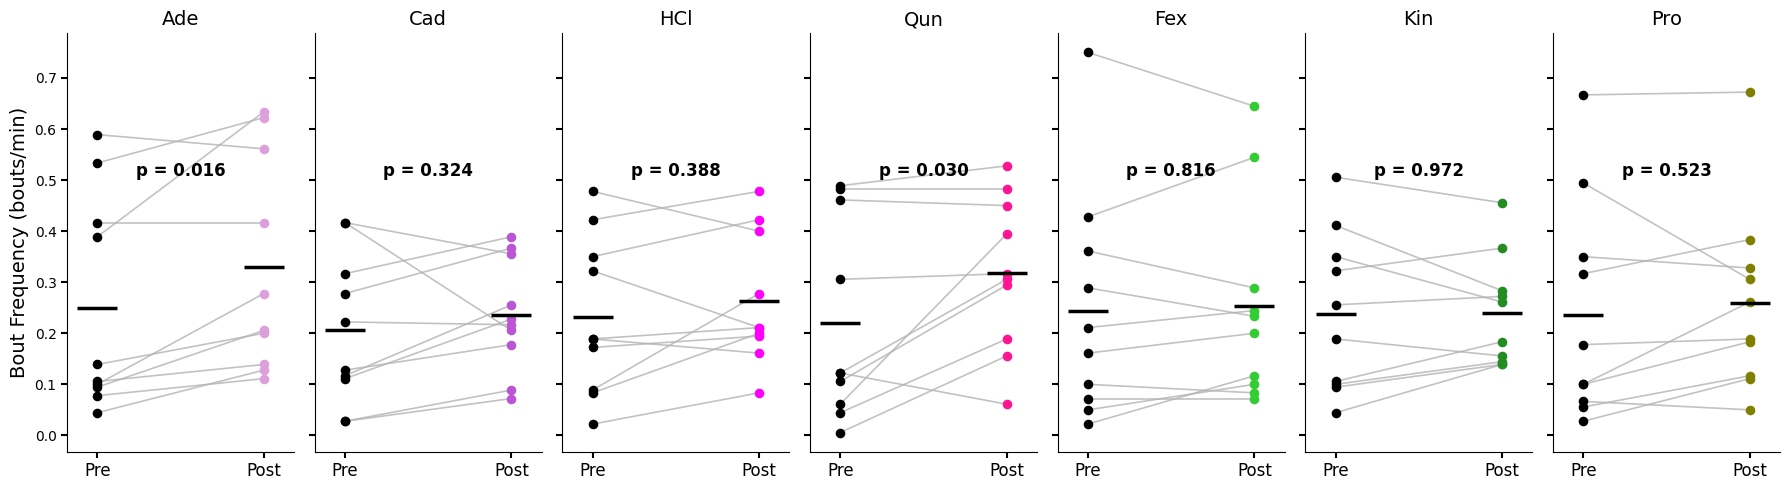

In [142]:
# -----------------------------
df_long = stimulus_df.melt(
    id_vars=["fish_id_clean", "stimulus", "trial_number", "session"],
    value_vars=["all_bout_freq_prestim", "all_bout_freq_poststim"],
    var_name="condition",
    value_name="bout_frequency"
)

df_long["condition"] = df_long["condition"].replace({
    "all_bout_freq_prestim": "Prestim",
    "all_bout_freq_poststim": "Poststim"
})

# if still in bouts/sec, uncomment this:
# df_long["bout_frequency"] *= 60

# convert stimulus names for plotting
df_long["stimulus"] = df_long["stimulus"].replace(stimulus_labels)

# -----------------------------
# 2. Average across trials within each fish
# -----------------------------
fish_plot_df = (
    df_long.groupby(["fish_id_clean", "stimulus", "condition"], as_index=False)["bout_frequency"]
    .mean()
)

fish_plot_df["stimulus"] = pd.Categorical(
    fish_plot_df["stimulus"],
    categories=stimulus_order,
    ordered=True
)

# -----------------------------
# 3. Prepare p-values for plotting
# -----------------------------
mixed_results_plot = mixed_results_all_bouts.copy()
mixed_results_plot["stimulus"] = mixed_results_plot["stimulus"].replace(stimulus_labels)

# -----------------------------
# 4. Plot
# -----------------------------
fig, axes = plt.subplots(1, len(stimulus_order), figsize=(18, 5), sharey=True)

for i, stim in enumerate(stimulus_order):
    ax = axes[i]

    stim_df = fish_plot_df[fish_plot_df["stimulus"] == stim]

    paired = stim_df.pivot_table(
        index="fish_id_clean",
        columns="condition",
        values="bout_frequency",
        aggfunc="mean"
    ).dropna()

    if paired.empty:
        ax.set_title(stim)
        continue

    # paired lines
    for _, row in paired.iterrows():
        ax.plot(
            [0, 1],
            [row["Prestim"], row["Poststim"]],
            color="0.7",
            linewidth=1.2,
            alpha=0.8,
            zorder=1
        )

    # individual fish points
    ax.scatter(
        np.zeros(len(paired)),
        paired["Prestim"],
        color="black",
        s=35,
        zorder=2
    )

    ax.scatter(
        np.ones(len(paired)),
        paired["Poststim"],
        color=stimulus_colors.get(stim, "gray"),
        s=35,
        zorder=2
    )

    # mean bars
    pre_mean = paired["Prestim"].mean()
    post_mean = paired["Poststim"].mean()

    ax.hlines(pre_mean, -0.12, 0.12, color="black", linewidth=2.5, zorder=3)
    ax.hlines(post_mean, 0.88, 1.12, color="black", linewidth=2.5, zorder=3)

    # numeric p-value
    p_row = mixed_results_plot[mixed_results_plot["stimulus"] == stim]
    if not p_row.empty:
        p = p_row.iloc[0]["p_value"]
        y = 0.5
        ax.text(
            0.5,
            y,
            f"p = {p:.3f}",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold"
        )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Pre", "Post"], fontsize=12)
    ax.set_title(stim, fontsize=14)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", width=1.5, length=4, direction="out")

axes[0].set_ylabel("Bout Frequency (bouts/min)", fontsize=14)

plt.tight_layout()
plt.show()